# FRAUD DETECTION ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# fraud.db: Tables, Columns & Relationships

## Relational Map

```
                    TRAIN SPLIT                                   TEST SPLIT
  ┌──────────────────────────────┐            ┌──────────────────────────────┐
  │      train_transaction       │            │       test_transaction       │
  │  590,540 rows · 394 cols     │            │  506,691 rows · 393 cols     │
  │  PK  TransactionID           │            │  PK  TransactionID           │
  │      isFraud  (target)       │            │      (no isFraud)            │
  └──────────────┬───────────────┘            └───────┬──────────────┬───────┘
                 │ 1                                  │ 1            │ 1
                 │                                    │              │
                 │ 0..1                               │ 0..1         │ 1
  ┌──────────────┴───────────────┐   ┌────────────────┴─────┐  ┌─────┴──────────────┐
  │        train_identity        │   │    test_identity     │  │ sample_submission  │
  │  144,233 rows · 41 cols      │   │ 141,907 rows · 41 cols│  │ 506,691 rows · 2   │
  │  PK/FK  TransactionID        │   │ PK/FK TransactionID  │  │ PK/FK TransactionID│
  └──────────────────────────────┘   └──────────────────────┘  └────────────────────┘

  Join key everywhere: TransactionID   ·   Train and test are NOT linked
```

| Parent | Child | Key | Cardinality | Coverage |
|---|---|---|---|---|
| `train_transaction` | `train_identity` | `TransactionID` | 1 : 0..1 | ~24% of transactions |
| `test_transaction` | `test_identity` | `TransactionID` | 1 : 0..1 | ~28% of transactions |
| `test_transaction` | `sample_submission` | `TransactionID` | 1 : 1 | 100% |

> **Tip:** Always `LEFT JOIN` the identity tables. An `INNER JOIN` drops about 76% of transactions.

---

## `train_transaction` (590,540 rows · 394 columns)

| Column(s) | Count | Type | Description |
|---|---|---|---|
| `TransactionID` | 1 | INTEGER | **Primary key**, used for joins |
| `isFraud` | 1 | INTEGER | **Target**: 1 = fraud, 0 = legit |
| `TransactionDT` | 1 | INTEGER | Seconds from a reference datetime (not a real timestamp) |
| `TransactionAmt` | 1 | REAL | Transaction amount in USD |
| `ProductCD` | 1 | TEXT | Product code (W, C, R, H, S) |
| `card1` – `card6` | 6 | mixed | Card info: `card4` = network (visa…), `card6` = debit/credit |
| `addr1`, `addr2` | 2 | REAL | Billing region / billing country |
| `dist1`, `dist2` | 2 | REAL | Distances (e.g. between addresses) |
| `P_emaildomain` | 1 | TEXT | Purchaser email domain |
| `R_emaildomain` | 1 | TEXT | Recipient email domain |
| `C1` – `C14` | 14 | REAL | Counts (e.g. addresses linked to the card) |
| `D1` – `D15` | 15 | REAL | Time deltas (e.g. days since previous transaction) |
| `M1` – `M9` | 9 | TEXT | Match flags (T/F), e.g. name on card vs. address |
| `V1` – `V339` | 339 | REAL | Vesta-engineered features (ranking, counting, relations) |

## `test_transaction` (506,691 rows · 393 columns)

Same columns as `train_transaction` **except `isFraud`**, which is what you predict.

---

## `train_identity` (144,233 rows · 41 columns)

| Column(s) | Count | Type | Description |
|---|---|---|---|
| `TransactionID` | 1 | INTEGER | **PK + FK** → `train_transaction.TransactionID` |
| `id_01` – `id_11` | 11 | REAL | Numeric identity features (network, device, browser signals) |
| `id_12` – `id_38` | 27 | mixed | Mostly categorical identity features (OS, browser, screen, flags) |
| `DeviceType` | 1 | TEXT | `desktop` or `mobile` |
| `DeviceInfo` | 1 | TEXT | Device / OS details |

## `test_identity` (141,907 rows · 41 columns)

Same columns as `train_identity`. The raw CSV used `id-01` … `id-38`, but they were **renamed to `id_01` … `id_38`** during loading.

---

## `sample_submission` (506,691 rows · 2 columns)

| Column | Type | Description |
|---|---|---|
| `TransactionID` | INTEGER | **PK + FK** → `test_transaction.TransactionID` |
| `isFraud` | REAL | Placeholder (0.5). Replace with your predicted fraud probability |

---

> **Note:** These keys are *logical*. `pandas.to_sql` doesn't create `PRIMARY KEY` / `FOREIGN KEY` constraints, so SQLite doesn't enforce them.


In [3]:
conn = sqlite3.connect("fraud.db")

query = """
SELECT 'train_transaction' AS table_name,
       (SELECT COUNT(*) FROM train_transaction) AS n_rows,
       (SELECT COUNT(*) FROM pragma_table_info('train_transaction')) AS n_cols
UNION ALL
SELECT 'train_identity',
       (SELECT COUNT(*) FROM train_identity),
       (SELECT COUNT(*) FROM pragma_table_info('train_identity'))
"""
pd.read_sql(query, conn)

,table_name,n_rows,n_cols
0,train_transaction,590540,394
1,train_identity,144233,41


# Transaction_Dataset

In [4]:
df_transaction_train = pd.read_sql("""
    SELECT *
    FROM train_transaction
""", conn)

print(f"shape: {df_transaction_train.shape}")
print("-"*1000)
print(df_transaction_train.info(verbose=True, show_counts=True))

shape: (590540, 394)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Confirming each transaction is unique and by Itself

In [5]:
df_transaction_train.TransactionID.nunique()

590540

In [6]:
df_transaction_train = df_transaction_train.drop(columns="TransactionID")

cat_set = df_transaction_train.select_dtypes(include=["object", "str"]).columns.tolist()
numerical = [c for c in df_transaction_train.columns if c not in cat_set]

print(cat_set)
print(numerical)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
['isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84

In [7]:
df_fraud = df_transaction_train[df_transaction_train["isFraud"] == 1]
df_legit = df_transaction_train[df_transaction_train["isFraud"] == 0]

# Categorical 

### How much of this is missing ---> Possibly does missing values within categorical mean more fraud?

In [9]:
missing = (df_transaction_train.isna().mean()*100).sort_values(ascending=False)

print(f"Columns with any missing: {(missing > 0).sum()} of {len(missing)}")
print(f"Columns > 50% missing: {(missing > 50).sum()}")
print(f"Columns > 90% missing: {(missing > 90).sum()}")

Columns with any missing: 374 of 393
Columns > 50% missing: 174
Columns > 90% missing: 2


In [14]:
cat_set = df_transaction_train.select_dtypes(include=["object", "str"]).columns.tolist()

for cat in cat_set:
    summary = (df_transaction_train
               .groupby(cat, dropna=False)["isFraud"]
               .agg(count="size", fraud_rate="mean")
               .sort_values("count", ascending=False)
               .head(10)
               )

    summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(1)

    n_null = df_transaction_train[cat].isna().sum()
    print(f"\n---- {cat} | unique: {df_transaction_train[cat].nunique()} | nulls: {n_null:,} ----")
    print(summary)



---- ProductCD | unique: 5 | nulls: 0 ----
            count  fraud_rate
ProductCD                    
W          439670         2.0
C           68519        11.7
R           37699         3.8
H           33024         4.8
S           11628         5.9

---- card4 | unique: 4 | nulls: 1,577 ----
                   count  fraud_rate
card4                               
visa              384767         3.5
mastercard        189217         3.4
american express    8328         2.9
discover            6651         7.7
NaN                 1577         2.6

---- card6 | unique: 4 | nulls: 1,571 ----
                  count  fraud_rate
card6                              
debit            439938         2.4
credit           148986         6.7
NaN                1571         2.5
debit or credit      30         0.0
charge card          15         0.0

---- P_emaildomain | unique: 59 | nulls: 94,456 ----
                count  fraud_rate
P_emaildomain                    
gmail.com      228355    

# Note 


# Numerical

# Train Identity exploration

In [10]:
df_identity_train = pd.read_sql("""
    SELECT *
    FROM train_identity
""", conn)

print(f"shape: {df_identity_train.shape}")
print("-" *1000)
print(df_identity_train.info(verbose=True, show_counts=True))

shape: (144233, 41)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [11]:
cat_set = df_identity_train.select_dtypes(include=["object", "str"]).columns.tolist() 


for col in cat_set:
    print(f"\n---- {col} ----")
    print(f"Unique Couont: {df_identity_train[col].nunique()}")
    print(df_identity_train[col].value_counts())


---- id_12 ----
Unique Couont: 2
id_12
NotFound    123025
Found        21208
Name: count, dtype: int64

---- id_15 ----
Unique Couont: 3
id_15
Found      67728
New        61612
Unknown    11645
Name: count, dtype: int64

---- id_16 ----
Unique Couont: 2
id_16
Found       66324
NotFound    63016
Name: count, dtype: int64

---- id_23 ----
Unique Couont: 3
id_23
IP_PROXY:TRANSPARENT    3489
IP_PROXY:ANONYMOUS      1071
IP_PROXY:HIDDEN          609
Name: count, dtype: int64

---- id_27 ----
Unique Couont: 2
id_27
Found       5155
NotFound      14
Name: count, dtype: int64

---- id_28 ----
Unique Couont: 2
id_28
Found    76232
New      64746
Name: count, dtype: int64

---- id_29 ----
Unique Couont: 2
id_29
Found       74926
NotFound    66052
Name: count, dtype: int64

---- id_30 ----
Unique Couont: 75
id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
                    ...  
func                   10
iOS

# Model Preperation

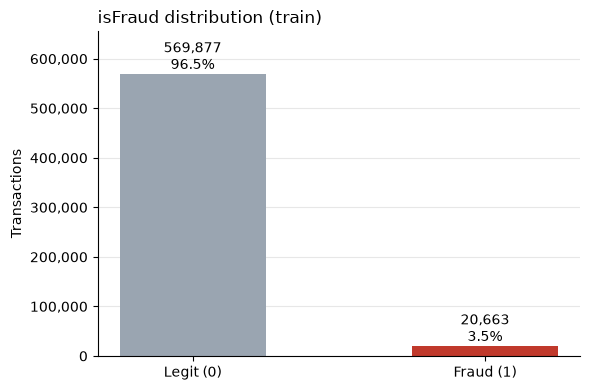

In [12]:
counts = df_transaction_train.isFraud.value_counts().sort_index()

pct = counts / counts.sum()*100
labels = ["Legit (0)", "Fraud (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=["#9aa5b1", "#c0392b"], width=0.5)

for bar, n, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{n:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("isFraud distribution (train)", loc="left", fontsize=12)
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True) 
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()


# Rises Problem
Our target variable (isFraud) is imbalanced. When training the model, the model will be trained and shaped for this specific distribution. Therefore, not allowing us to generalize our model to classify whether a transaction is fraudulant or not. 

# Notes for underfit....
This will underfit our data for multiple reasons. One the model won't be able to generalize it's shape or model to classify Legit and Fraud transactions. 

**Helpful** What is helpful about this data set is the features that weere engineered... id (identity) data which aren't specified but provided are each id is a count of what IP, IPS, Proxy, etc. the transaction occured. This is helpful because it helps us see how many of these transactions came from a specific spot

**Helpful** Vesta-engineered features (V_{id}) similar to the Id feature, it also identifies the frequency of an email's, IP or address that the transaction occured within a 24-hr period. 



# Narrow Down Our Analysis

### Baseline: Logistic Regression

### Unsupervised Learning Clustering, DBSCAN

### Comparison: XGBoost & RandomForrest